Predicting employee Attrition using Machine Learning

Predicting turnover means dealing with the intricacies of a chaotic system (humans) operating in a highly sensitive environment, simply because one variable can impact another one and so forth, affecting people's behaviour and their relationships.

However, Machine Learning provides us with enough data to model past outcomes and estimate future behaviour based on those patterns.

Turnover is a non-negligible cost for each organisation. Depending on the regulations and labour law applicable in each country, replacing an employee typically costs several months of salary once recruiting, onboarding, and lost productivity are taken into account. More importantly, as Jean Emannuel Ray (2024) highlighted, for organisations, particularly those operating in the tertiary sector, « il n'est de richesse que les hommes ». Any mistake can therefore be costly, both immediately and in the long term, financially as well as psychologically.

This study is based on the dataset provided by IBM, named HR Analytics.

Methodology:
-   Explore the data and check for class imbalance;
-   Feature engineering;
-   Train and compare Logistic Regression and Random Forest models;
-   Use SHAP to interpret the selected model.

In [138]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("dataset.csv", sep="\t", encoding='utf-8')

print (f"dataset shape: {df.shape}")

print (df.info())


dataset shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                 

In [139]:
for column in df.columns:
    if df[column].dtype!=object:
        print("{}:{}:{}".format(column,df[column].min(), df[column].max()))

Age:18:60
Attrition:No:Yes
BusinessTravel:Non-Travel:Travel_Rarely
DailyRate:102:1499
Department:Human Resources:Sales
DistanceFromHome:1:29
Education:1:5
EducationField:Human Resources:Technical Degree
EmployeeCount:1:1
EmployeeNumber:1:2068
EnvironmentSatisfaction:1:4
Gender:Female:Male
HourlyRate:30:100
JobInvolvement:1:4
JobLevel:1:5
JobRole:Healthcare Representative:Sales Representative
JobSatisfaction:1:4
MaritalStatus:Divorced:Single
MonthlyIncome:1009:19999
MonthlyRate:2094:26999
NumCompaniesWorked:0:9
Over18:Y:Y
OverTime:No:Yes
PercentSalaryHike:11:25
PerformanceRating:3:4
RelationshipSatisfaction:1:4
StandardHours:80:80
StockOptionLevel:0:3
TotalWorkingYears:0:40
TrainingTimesLastYear:0:6
WorkLifeBalance:1:4
YearsAtCompany:0:40
YearsInCurrentRole:0:18
YearsSinceLastPromotion:0:15
YearsWithCurrManager:0:17


In [140]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

Cleaning

In [141]:
df.drop(['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], axis=1, inplace=True)
print(f"columns: {len(df.columns)}")

columns: 31


In [142]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [143]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [144]:
df.nunique() 

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBalance                4
YearsAtCompany                37
YearsInCurrentRole            19
YearsSinceLastPromotion       16
YearsWithC

Exploratory data analysis

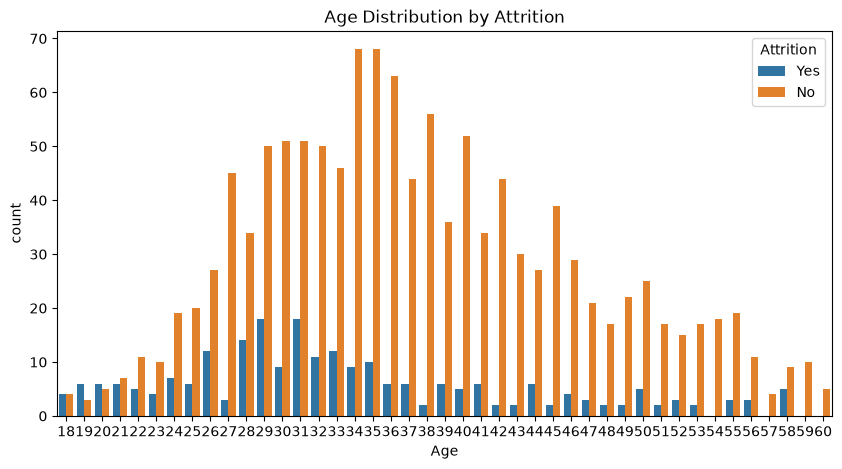

In [145]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 5))
sns.countplot (data=df, x='Age', hue='Attrition')
plt.title("Age Distribution by Attrition")
plt.show()

In [146]:
df.groupby('Gender')['Attrition'].value_counts(normalize=True)

Gender  Attrition
Female  No           0.852041
        Yes          0.147959
Male    No           0.829932
        Yes          0.170068
Name: proportion, dtype: float64

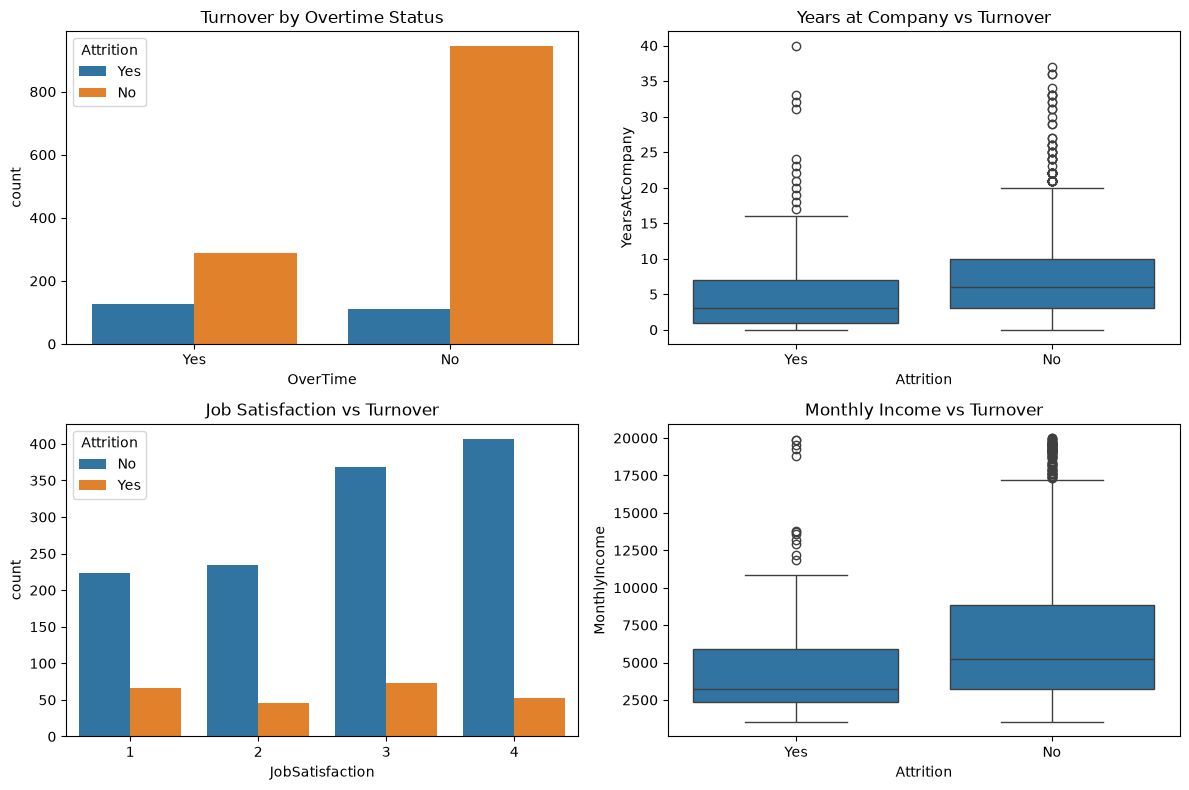

In [147]:
# Exploratory analysis

# Varibales related to turnover
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Overtime and Attrition
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[0, 0])
axes[0, 0].set_title('Turnover by Overtime Status')

# Years at Company and Attrition
sns.boxplot(data=df, x='Attrition', y='YearsAtCompany', ax=axes[0, 1])
axes[0, 1].set_title('Years at Company vs Turnover')

# Salary and Attrition
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', ax=axes[1, 1])
axes[1, 1].set_title('Monthly Income vs Turnover')

# Job Satisfaction and Attrition
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', ax=axes[1, 0])
axes[1, 0].set_title('Job Satisfaction vs Turnover')

plt.tight_layout()
plt.show()

Feature Engineering 

In [148]:
# Overtime combined with distance from home
df["OverTime"] = df["OverTime"].map({'Yes': 1, 'No': 0})
df["Overtime_distance"] = df["OverTime"] * df["DistanceFromHome"] 
print("Created: Overtime_distance")

Created: Overtime_distance


In [149]:
# Years with the current manager combined with relationship 
df["Manager_relationship"] = df["YearsWithCurrManager"] * df["RelationshipSatisfaction"]
print("Created: Manager_relationship")

Created: Manager_relationship


In [150]:
# Years in the current role combined with years since last promotion
df["Stagnation"] = (df["YearsInCurrentRole"] - df["YearsSinceLastPromotion"])
print("Created: Stagnation")

Created: Stagnation


Split and Encoding 

In [151]:
from sklearn.model_selection import train_test_split

# Encode (y)
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

# Split before encoding 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# One hot encoding
X_train = pd.get_dummies(X_train, drop_first=True).astype(float)
X_test = pd.get_dummies(X_test, drop_first=True).astype(float)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Modeling
1. Logistic regression 

In [152]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report


pipe = make_pipeline(StandardScaler(), LogisticRegression())
pipe.fit(X_train, y_train)

print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



2. Random forest

In [153]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

print(classification_report(y_test, classifier.predict(X_test)))


              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.60      0.13      0.21        47

    accuracy                           0.85       294
   macro avg       0.73      0.56      0.56       294
weighted avg       0.81      0.85      0.80       294



Logistic Regression seems to perform better than Random Forest. This first iteration allows us to establish a baseline and understand that class imbalance was blinding our models, leading us to use class_weight (balanced) in the next step to better capture minority cases and improve recall, which is essential in an HR context where missing a potential leaver is more costly than a false alarm.

Balanced logistic regression

In [154]:

pipe_balanced = make_pipeline(StandardScaler(), LogisticRegression(class_weight="balanced", random_state=42))
pipe_balanced.fit(X_train, y_train)

print(classification_report(y_test, pipe_balanced.predict(X_test)))

              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.45        47

    accuracy                           0.76       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.76      0.78       294



Balanced random forest

In [155]:

classifier_balanced = RandomForestClassifier(class_weight="balanced", random_state=42)
classifier_balanced.fit(X_train, y_train)

print(classification_report(y_test, classifier_balanced.predict(X_test)))


              precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.53      0.36      0.43        47

    accuracy                           0.85       294
   macro avg       0.71      0.65      0.67       294
weighted avg       0.83      0.85      0.83       294



SHAP 

We use SHAP to understand why the model makes its predictions. This also allows us to translate the model’s behaviour into human readable insights, helping us identify which factors push employees toward leaving and which ones encourage them to stay.

In [156]:
import shap
model = LogisticRegression(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)


Background dataset has 1176 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1176 when initializing the masker.


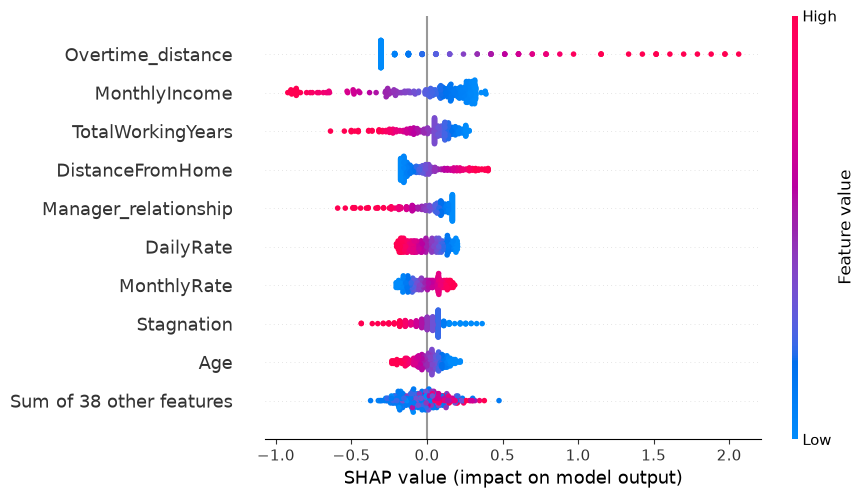

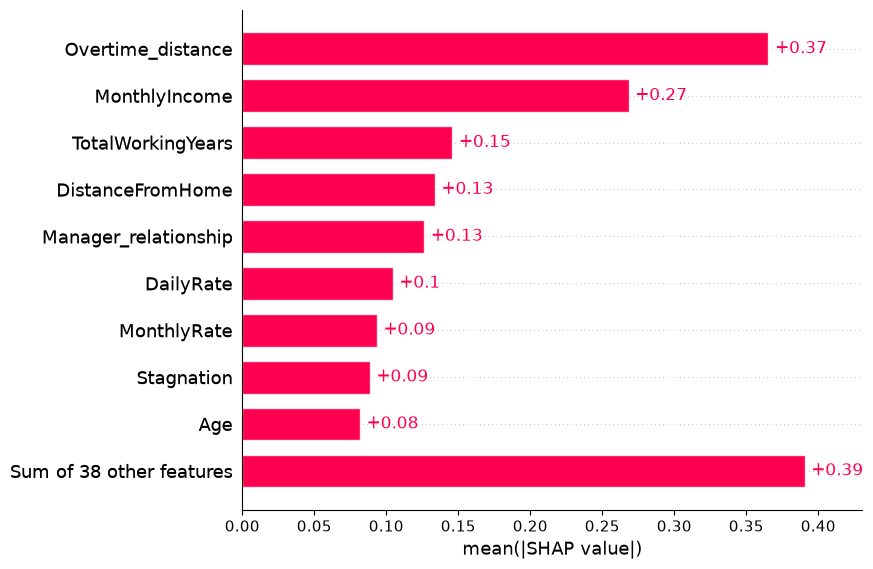

In [157]:
# Visualization
shap.plots.beeswarm(shap_values)
shap.plots.bar(shap_values.abs.mean(0))

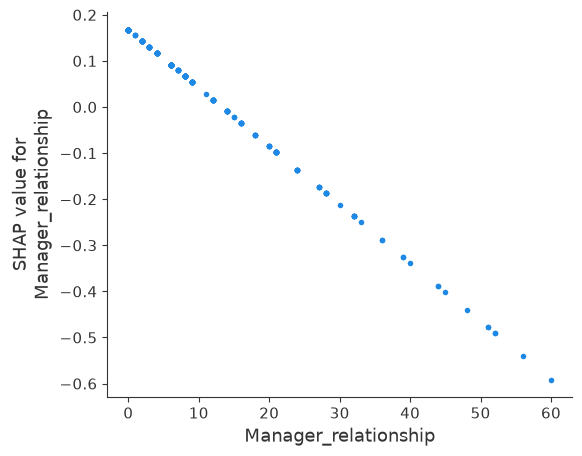

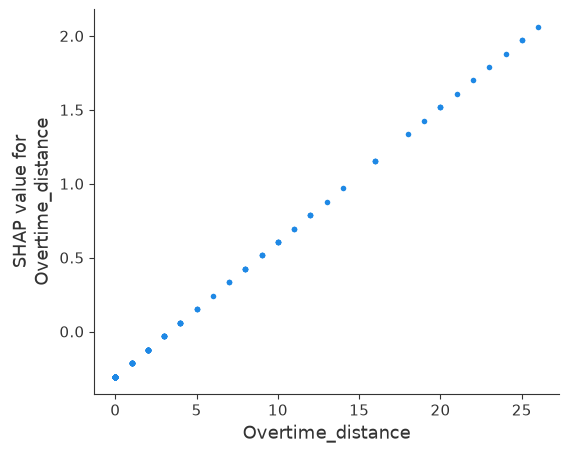

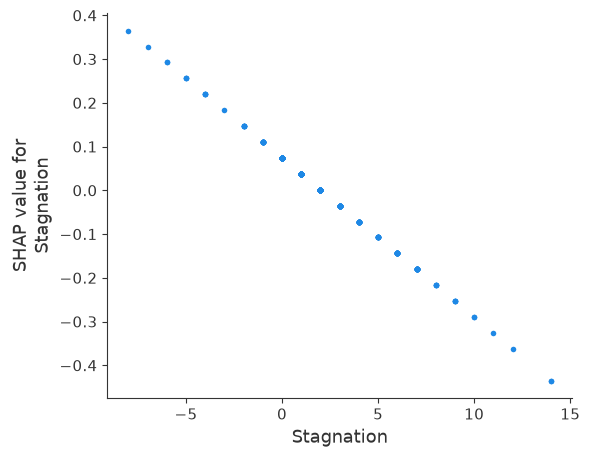

In [158]:
# Dependance plot
shap.dependence_plot("Manager_relationship", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("Overtime_distance", shap_values.values, X_test, interaction_index=None)
shap.dependence_plot("Stagnation", shap_values.values, X_test, interaction_index=None)


Conclusion

To sum up this work, we can highlight how SHAP gave us an unparalleled understanding of why the selected model makes its predictions.

Overtime combined with distance from home significantly increases the chance of turnover (+0.37). I strongly recommend considering remote work arrangements for employees who have a long commute and a willingness to work more.

In HR, one of the highest sources of turnover remains the manager. The relationship with employees, poor management practices, or even the manager's departure are some key elements that highly increase turnover. In this regard, I recommend investing in management training to improve soft skills, as well as implementing 360-degree interviews and feedback loops to ensure effective communication.

In cases of career stagnation, employees who have stayed in the same role for a long period without promotion are more likely to leave. I strongly recommend considering every employee as a talent to invest in. Each of them should have opportunities not only to grow but also to reinvent themselves. For instance, rotation programs allow employees to explore new opportunities, fostering internal mobility. It might also be substantial to review promotion cadence. From a behavioural economics perspective, removing bonuses may generate a sense of loss that is much stronger than the satisfaction experienced from receiving an equivalent bonus. On the other hand, if the absence of bonuses constitutes the organisational norm, the issue is likely to be more related to a poor recognition and limited perceptions of career advancement.



Limits

As mentioned at the beginning, dealing with humans means dealing with a chaotic system in a highly sensitive environment. Human behaviour is inherently unpredictable: a bad mood, indigestion, slow traffic on the way to work, or a fight with a spouse can all influence decisions in ways that are difficult to capture in a dataset.

Furthermore, while SHAP provided valuable insights into the model's predictions, the analysis focused primarily on the balanced logistic regression and did not explore explanations for the Random Forest model or other models. Future research should extend explainability techniques and compare the insights generated across several predictive models.

Finally, although the IBM dataset provides substantial sources of information, it remains a synthetic dataset and may not fully capture the intricacies of a real company. In social data science, a key question is whether a model trained on such data would transfer to organisations with different cultures, structures, or managerial practices.